# Train a handwritten ABC classifier

## Vision Statement 

This is a simple image classifier to distinguish the handwritten letters A(a), B(b), and C(c) based on Lab 1 notebook.


## Data

The dataset contains handwritten letters A, B, and C, collected manually from my friends to capture different handwriting styles. Each image was labeled accordingly and organized into three folders: A, B, and C.

The dataset is available on Kaggle: [testletter](https://www.kaggle.com/datasets/sylviali4/testletter).

**Dataset Overview**:

A: 65 images

B: 65 images

C: 65 images

Total: 196 images

Format: JPEG

## Set up
Import Required Libraries

In [35]:
# Check versions of Keras and Tensorflow
!pip list | egrep 'keras|tensorflow$'

keras                              3.5.0
keras-core                         0.1.7
keras-cv                           0.9.0
keras-hub                          0.18.1
keras-nlp                          0.18.1
keras-tuner                        1.4.7
tf_keras                           2.17.0


In [36]:
import os
# Results are better with the TensorFlow backend; this is probably a bug in Keras 3 but I haven't tracked it down.
os.environ["KERAS_BACKEND"] = "tensorflow"

from IPython.display import display, HTML
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import keras
import keras_cv
import tensorflow as tf
import tensorflow_datasets as tfds

# Print versions to confirm proper installation
print(f"Keras version: {keras.__version__}, backend: {keras.backend.backend()}")

# Check GPU availability
num_gpus = len(tf.config.list_physical_devices('GPU'))
print(f"GPUs: {num_gpus}")

# Display a warning if no GPUs are detected
if num_gpus == 0:
    display(HTML("No GPUs available. Training will be slow. <b>Please enable an accelerator.</b>"))

Keras version: 3.5.0, backend: tensorflow
GPUs: 1


## Configure our experiments

I increased epochs from 1 to 4, to allow training for multiple iterations.

I also reduced image size from (256, 256) to (64, 64) to speed up training.

In [40]:
class config:
    seed = 123
    learning_rate = 1e-3
    epochs = 4  # Increase to allow training for multiple iterations
    batch_size = 16  # can experiment with 16 or 32
    image_size = (64, 64)  # Reduce from (256, 256) to (64, 64) to speed up training
    model_preset = "efficientnetv2_b0_imagenet"  # Pretrained model
    use_zero_init = True

# Reproducibility
keras.utils.set_random_seed(config.seed)

# this makes GPU operations deterministic
tf.config.experimental.enable_op_determinism()


## Load the Data

In [44]:
# Define paths
dataset_path = Path("/kaggle/input/testletter") 

# Define class names (optional, but useful for checking)
class_names = ['A', 'B', 'C']

# Create training and validation datasets
train_dataset, val_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,  # 80% training, 20% validation
    labels='inferred', # default
    label_mode='int', # default
    image_size=config.image_size,
    batch_size=config.batch_size,
    shuffle=True, # randomizes the order of images when loading the dataset
    seed=config.seed,  # Ensure reproducibility
    subset="both",
    crop_to_aspect_ratio=True   
)

# Check dataset
print("Class names:", train_dataset.class_names)


Found 195 files belonging to 3 classes.
Using 156 files for training.
Using 39 files for validation.
Class names: ['A', 'B', 'C']


After we successfully uploaded the dataset, we can show some example images in our dataset.

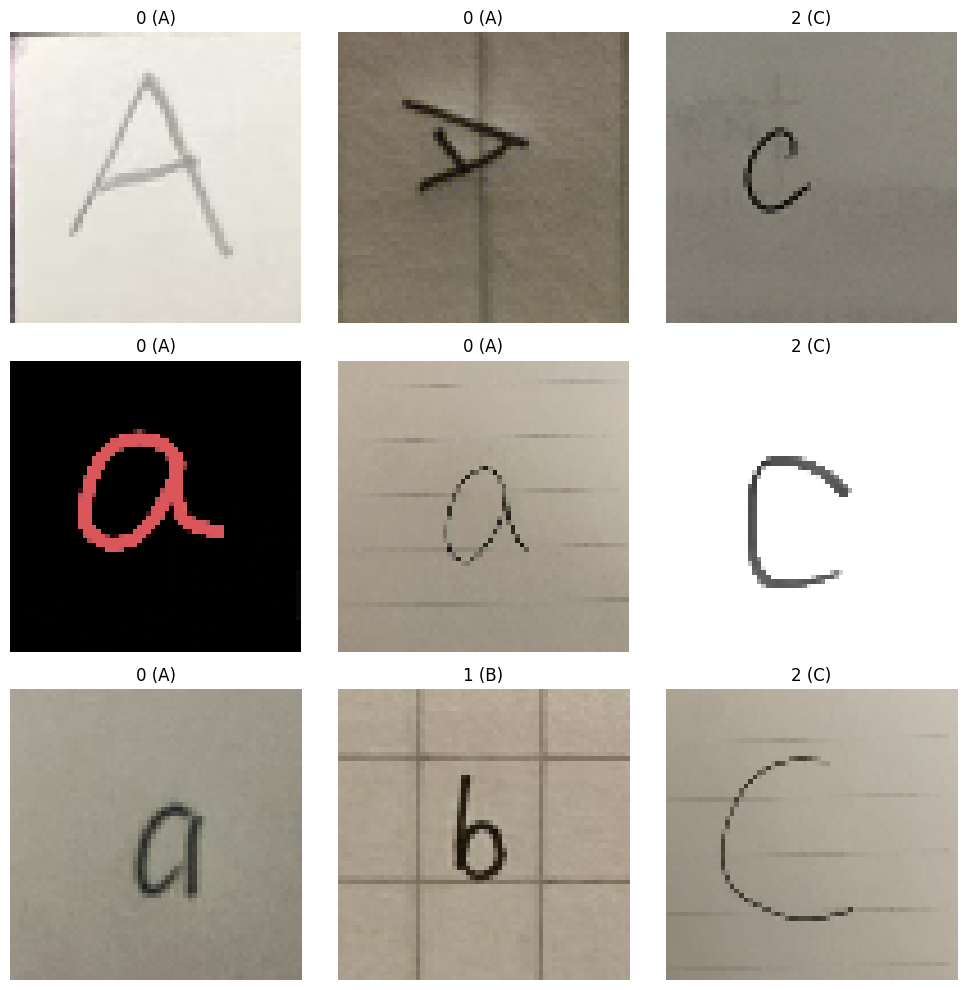

In [47]:
# Extract a batch of images and labels
[[example_images, example_labels]] = train_dataset.take(1)  

# Plot images
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(np.array(example_images[i]).astype('uint8'))
    
    # Get integer label
    label = example_labels[i].numpy()  # Convert tensor to int
    
    # Show integer + class name
    ax.set(title=f"{label} ({class_names[label]})")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Optional: Use KerasCV for quick visualization (without labels)
# keras_cv.visualization.plot_image_gallery(example_images, value_range=(0, 255))

## Train a model

### Check Overall Accuracy

After checeking some example images, now I'm going to train the model and check its accuracy.

In [48]:
# Create a model using a pretrained backbone
# See https://keras.io/api/keras_cv/models/tasks/image_classifier/ for options
model = keras_cv.models.ImageClassifier.from_preset(
    config.model_preset,  # "efficientnetv2_b0_imagenet"
    num_classes=3  # We have 3 classes: A, B, and C
)

# Zero the output-layer weights to improve fine-tuning stability
if config.use_zero_init:
    output_layer = model.layers[-1]
    output_layer.set_weights([w * 0 for w in output_layer.weights])

# Compile the model for training
model.compile(
    loss="sparse_categorical_crossentropy",  
    optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate),
    metrics=["accuracy"]
)

# Print model summary
model.summary(show_trainable=True)

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=config.epochs
)

Model: "image_classifier_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_7 (InputLayer)          │ (None, None, None, 3)        │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ efficient_net_v2b0_backbone         │ (None, None, None, 1280)     │     5,919,312 │    Y    │
│ (EfficientNetV2Backbone)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ avg_pool (GlobalAveragePooling2D)   │ (None, 1280)                 │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ predictions (Dense)                 │ (None, 3)                    │         3,843 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 5,923,155 (22.60 MB)

 Trainable params: 5,862,547 (22.36 MB)

 Non-trainable params: 60,608 (236.75 KB)

Epoch 1/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.5097 - loss: 1.0806 - val_accuracy: 0.3590 - val_loss: 1.0560
Epoch 2/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 515ms/step - accuracy: 0.6291 - loss: 0.8803 - val_accuracy: 0.4872 - val_loss: 0.8402
Epoch 3/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 513ms/step - accuracy: 0.8133 - loss: 0.5684 - val_accuracy: 0.6923 - val_loss: 0.6913
Epoch 4/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 512ms/step - accuracy: 0.8787 - loss: 0.3215 - val_accuracy: 0.7692 - val_loss: 0.5194


**After 4 epoches training:**

Training set accuracy: 87.87%

Validation set accuracy: 76.92%

Training loss: 0.3215

Validation loss: 0.5194

### Which Letter is Classified Best

Now, I'm going to check which letter A, B, or C the model predicts most correctly.

In [49]:
# Get predictions on validation data
true_labels = []
predicted_labels = []

for images, labels in val_dataset:
    preds = model.predict(images)
    predicted_labels.extend(np.argmax(preds, axis=1))  # Convert softmax output to class index
    true_labels.extend(labels.numpy())  # Get actual class labels

# Convert lists to numpy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Calculate accuracy for each class (A, B, C)
class_names = ['A', 'B', 'C']
for i, class_name in enumerate(class_names):
    correct = np.sum((true_labels == i) & (predicted_labels == i))
    total = np.sum(true_labels == i)
    accuracy = correct / total if total > 0 else 0
    print(f"Accuracy for letter {class_name}: {accuracy:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Accuracy for letter A: 75.00%
Accuracy for letter B: 71.43%
Accuracy for letter C: 90.00%


* Reference:
I got help of this code for evaluating accuracy per class from ChatGPT. The prompt used was: How do I check accuracy for each class in my model?

* From the output, we can see that letter C is been classified most successfully. 



I will show an example of correctly classified image below.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


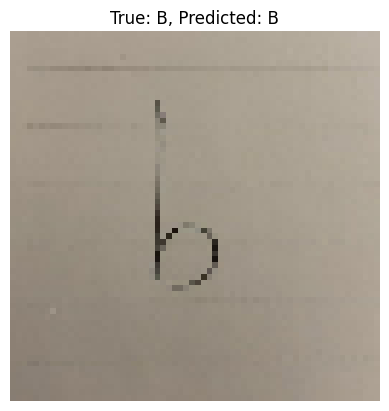

In [50]:
# Display a correctly classified image
for images, labels in val_dataset.take(1):
    preds = model.predict(images)
    predicted_labels_batch = np.argmax(preds, axis=1)

    # Find the first correctly classified image
    for i in range(len(labels)):
        if predicted_labels_batch[i] == labels[i]:  # Correctly classified
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"True: {class_names[labels[i]]}, Predicted: {class_names[predicted_labels_batch[i]]}")
            plt.axis("off")
            plt.show()
            break  # Stop after finding one correct example
    

* Reference: 
I got help from ChatGPT for this code to show an correctly classified image example. The prompt used was: How do I get one correctly classified image example for one class in my model?

### the Most Common Mistakes

In [53]:
from collections import Counter

# Count the most common mistakes
mistakes = [(true, pred) for true, pred in zip(true_labels, predicted_labels) if true != pred]
mistake_counts = Counter(mistakes)

# Print most common mistakes
print("Most common mistakes:")
for (true, pred), count in mistake_counts.most_common():
    print(f"True: {class_names[true]}, Predicted: {class_names[pred]} - {count} times")


Most common mistakes:
True: B, Predicted: A - 5 times
True: C, Predicted: A - 1 times
True: A, Predicted: C - 1 times
True: B, Predicted: C - 1 times
True: A, Predicted: B - 1 times


* It looks the model misclassifies B as A frequently. These letters might look similar due to handwriting style.

Following is an example of misclassfied image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


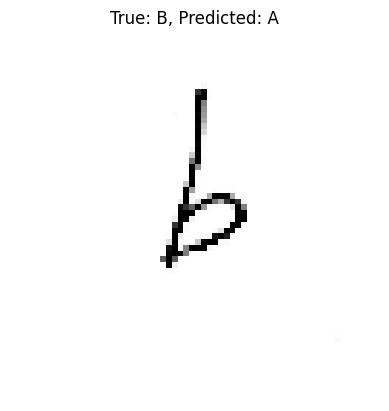

In [54]:
# Find an image where the model made the most common mistake
most_common_mistake = mistake_counts.most_common(1)[0][0]  # (true_label, predicted_label)
true_mistake_label, pred_mistake_label = most_common_mistake

# Display the first occurrence of this mistake
for images, labels in val_dataset:
    preds = model.predict(images)
    predicted_labels_batch = np.argmax(preds, axis=1)

    for i in range(len(labels)):
        if labels[i] == true_mistake_label and predicted_labels_batch[i] == pred_mistake_label:
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(f"True: {class_names[true_mistake_label]}, Predicted: {class_names[pred_mistake_label]}")
            plt.axis("off")
            plt.show()
            break
    break  # Only process the first batch


### Generalization Analysis

Based on my validation accuracy of 76.92%, I estimate that my classifier would correctly classify a new, unseen image about 76.92% of the time.

When broken down by letter:

A: 75% accuracy

B: 71% accuracy

C: 90% accuracy

If the new image is similar to the training images like same handwriting style, the classifier is more likely to get it right. However, if the image is very different like new handwriting style, the accuracy may drop.

## Conclusion

In this project, I made som key decision in the process of collecting data, processing it, and analyzing the results:

I selected same number of handwritten images for each class(A,B,C), resized them to 64×64 pixels to speed up, increased epoch from 1 to 4 to allow training for multiple iterations, and used sparse_categorical_crossentropy as the loss function because my labels were stored as integers.

### Alternative Choices & Impact:

**Larger Dataset**: More images could improve accuracy and generalization.

**More Epochs**: Increase the number of epochs would allow the model to learn patterns more effectively.

**Data Augmentation**: Applying rotation or brightness adjustments could help the model recognize more handwriting styles.

While the model performed well, these improvements could further enhance its accuracy.